# 🏢 Hierarchical Agents in LangGraph

## Learning Objectives
In this notebook, you will learn:
1. **Subgraphs as departments** - compile independent LangGraph graphs and plug each one in as a single node of a parent graph.
2. **Shared state contracts** - design one `TeamState` schema that every department subgraph and the parent supervisor can read and write.
3. **Fan-out / fan-in patterns** - run multiple specialists in parallel inside a department, then merge their outputs with a lead node.
4. **LLM-based routing** - use structured output (`with_structured_output`) so a top-level "CEO" supervisor picks the right department for a request.
5. **Tracing multi-level execution** - inspect the full message trace across supervisor -> department -> specialist to understand how state flows through a hierarchy.

## Prerequisites
- Familiarity with core LangGraph concepts: `StateGraph`, `START`/`END`, conditional edges (see `03_LangGraph_Fundamentals/`).
- Comfort with single-level supervisor / multi-agent patterns (see earlier notebooks in `04_Multi_Agent_Systems/`).
- An `OPENAI_API_KEY` set in a `.env` file at the project root (loaded via `python-dotenv`).
- Basic understanding of Pydantic models for structured LLM output.

---
## 🔧 Part 0: Environment Setup

This section loads environment variables and initializes the shared LLM used by every node in this notebook - the CEO supervisor, every department lead, and every individual specialist. Keeping one shared `llm` instance keeps the example simple; in production each department might use a different model tuned to its task.

In [11]:
# ============================================================================
# IMPORTS AND SETUP: Load environment, initialize LLM
# ============================================================================
from typing import Literal

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing_extensions import Annotated, TypedDict

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages

load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

print(f"🤖 LLM initialized: {llm.model_name}")
print("✅ Environment ready.")

🤖 LLM initialized: gpt-4o-mini
✅ Environment ready.


---
## 📦 Part 1: Shared State Schema

Every level of the hierarchy - the parent supervisor and each department subgraph - operates over the *same* state schema. That is what makes a compiled subgraph pluggable as a single node in the parent graph: the parent just needs to speak the same `TeamState` "language" as the child.

### Key Concepts:
- **`messages`**: the shared conversation history, using LangGraph's `add_messages` reducer so new messages are appended rather than overwriting the list.
- **`final_answer`**: a scratch field each department's "lead" node writes to, so the parent graph can read a single clean output regardless of which department handled the request.

In [12]:
# ============================================================================
# TEAM STATE: Shared state schema used across all levels
# ============================================================================
class TeamState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    final_answer: str

---
## 🏛️ Part 2: Department Subgraphs

Each department below is built as its own independent `StateGraph`, compiled on its own, and later attached to the parent graph as a single node. This is the core idea of hierarchical agent systems: complexity is hidden inside subgraphs, so the top-level graph only has to reason about "which department" rather than "which of N specialists".

### 2.1 🔬 Research Team

The research department fans out to two specialists that run independently - a web researcher and a paper reviewer - then fans back in to a research lead that synthesizes both findings into a single brief.

In [13]:
# ============================================================================
# BUILD_RESEARCH_TEAM: Research department: web + paper specialists -> lead
# ============================================================================
def build_research_team() -> StateGraph:
    """Build the research department subgraph."""

    def web_researcher(state: TeamState) -> dict:
        """Searches the web for information."""
        # Extract the query from the last human message
        query = ""
        for msg in reversed(state["messages"]):
            if isinstance(msg, HumanMessage):
                query = msg.content
                break

        response = llm.invoke(
            [
                SystemMessage(
                    content=(
                        "You are a web researcher. Find key facts and data about "
                        "the topic. Provide 3-4 bullet points of findings. Be specific."
                    )
                ),
                HumanMessage(content=query),
            ]
        )
        return {
            "messages": [
                AIMessage(
                    content=f"[WEB RESEARCHER]: {response.content}",
                    name="web_researcher",
                )
            ]
        }

    def paper_reviewer(state: TeamState) -> dict:
        """Reviews academic/technical sources."""
        query = ""
        for msg in reversed(state["messages"]):
            if isinstance(msg, HumanMessage):
                query = msg.content
                break

        response = llm.invoke(
            [
                SystemMessage(
                    content=(
                        "You are an academic reviewer. Provide technical depth and "
                        "cite relevant concepts or frameworks. 3-4 bullet points."
                    )
                ),
                HumanMessage(content=query),
            ]
        )
        return {
            "messages": [
                AIMessage(
                    content=f"[PAPER REVIEWER]: {response.content}",
                    name="paper_reviewer",
                )
            ]
        }

    def research_lead(state: TeamState) -> dict:
        """Synthesizes findings from both researchers."""
        response = llm.invoke(
            [
                SystemMessage(
                    content=(
                        "You are the research lead. Synthesize the web researcher's "
                        "and paper reviewer's findings into a cohesive research brief. "
                        "Keep it to one short paragraph."
                    )
                ),
                *state["messages"],
            ]
        )
        return {
            "messages": [
                AIMessage(
                    content=f"[RESEARCH LEAD]: {response.content}", name="research_lead"
                )
            ],
            "final_answer": response.content,
        }

    # Build the research subgraph
    research_graph = StateGraph(TeamState)
    research_graph.add_node("web_researcher", web_researcher)
    research_graph.add_node("paper_reviewer", paper_reviewer)
    research_graph.add_node("research_lead", research_lead)

    # Fan-out: both researchers work in parallel
    research_graph.add_edge(START, "web_researcher")
    research_graph.add_edge(START, "paper_reviewer")

    # Fan-in: both feed into the research lead
    research_graph.add_edge("web_researcher", "research_lead")
    research_graph.add_edge("paper_reviewer", "research_lead")
    research_graph.add_edge("research_lead", END)

    return research_graph

#### 🧪 Try it: Single Department in Isolation

Before wiring departments into the full hierarchy, it helps to run one department subgraph on its own to confirm the fan-out/fan-in wiring behaves as expected.

In [14]:
# ============================================================================
# DEMO_SINGLE_DEPARTMENT: Run the research team subgraph standalone
# ============================================================================
def demo_single_department():
    """Demo a single department subgraph in isolation."""
    print("Single Department Demo (Research Team):\n")

    research_team = build_research_team().compile()
    result = research_team.invoke(
        {
            "messages": [
                HumanMessage(content="What is retrieval-augmented generation (RAG)?")
            ],
            "final_answer": "",
        }
    )

    for msg in result["messages"]:
        if isinstance(msg, AIMessage):
            print(f"{msg.content[:200]}...\n")

    print(f"Research Brief:\n{result['final_answer']}")

### 2.2 ✍️ Content Team

The content department is a simple linear pipeline: a writer drafts a piece using whatever context is already in the conversation (e.g. a research brief), then an editor polishes it into the final answer.

In [15]:
# ============================================================================
# BUILD_CONTENT_TEAM: Content department: writer -> editor pipeline
# ============================================================================
def build_content_team() -> StateGraph:
    """Build the content department subgraph."""

    def content_writer(state: TeamState) -> dict:
        """Writes content based on available context."""
        response = llm.invoke(
            [
                SystemMessage(
                    content=(
                        "You are a skilled content writer. Using any research or context "
                        "in the conversation, write a clear, engaging short piece "
                        "(one paragraph). Match a professional but accessible tone."
                    )
                ),
                *state["messages"],
            ]
        )
        return {
            "messages": [
                AIMessage(
                    content=f"[WRITER]: {response.content}", name="content_writer"
                )
            ]
        }

    def content_editor(state: TeamState) -> dict:
        """Edits and polishes the writer's output."""
        response = llm.invoke(
            [
                SystemMessage(
                    content=(
                        "You are a content editor. Take the writer's draft and "
                        "improve clarity, fix any issues, and tighten the language. "
                        "Return the polished version only."
                    )
                ),
                *state["messages"],
            ]
        )
        return {
            "messages": [
                AIMessage(
                    content=f"[EDITOR]: {response.content}", name="content_editor"
                )
            ],
            "final_answer": response.content,
        }

    content_graph = StateGraph(TeamState)
    content_graph.add_node("writer", content_writer)
    content_graph.add_node("editor", content_editor)
    content_graph.add_edge(START, "writer")
    content_graph.add_edge("writer", "editor")
    content_graph.add_edge("editor", END)

    return content_graph

### 2.3 📊 Analysis Team

The analysis department is also linear: a data analyst produces quantitative findings, and a strategy advisor turns those findings into actionable recommendations.

In [16]:
# ============================================================================
# BUILD_ANALYSIS_TEAM: Analysis department: data analyst -> strategy advisor
# ============================================================================
def build_analysis_team() -> StateGraph:
    """Build the analysis department subgraph."""

    def data_analyst(state: TeamState) -> dict:
        """Provides data-driven analysis."""
        response = llm.invoke(
            [
                SystemMessage(
                    content=(
                        "You are a data analyst. Analyze the topic with numbers, "
                        "trends, and quantitative reasoning. Provide 3-4 data-driven "
                        "insights. Make up plausible stats for demonstration."
                    )
                ),
                *state["messages"],
            ]
        )
        return {
            "messages": [
                AIMessage(
                    content=f"[DATA ANALYST]: {response.content}", name="data_analyst"
                )
            ]
        }

    def strategy_advisor(state: TeamState) -> dict:
        """Provides strategic recommendations."""
        response = llm.invoke(
            [
                SystemMessage(
                    content=(
                        "You are a strategy advisor. Based on the data analysis in the "
                        "conversation, provide 3 actionable strategic recommendations. "
                        "Be specific and practical."
                    )
                ),
                *state["messages"],
            ]
        )
        return {
            "messages": [
                AIMessage(
                    content=f"[STRATEGY ADVISOR]: {response.content}",
                    name="strategy_advisor",
                )
            ],
            "final_answer": response.content,
        }

    analysis_graph = StateGraph(TeamState)
    analysis_graph.add_node("data_analyst", data_analyst)
    analysis_graph.add_node("strategy_advisor", strategy_advisor)
    analysis_graph.add_edge(START, "data_analyst")
    analysis_graph.add_edge("data_analyst", "strategy_advisor")
    analysis_graph.add_edge("strategy_advisor", END)

    return analysis_graph

---
## 🎯 Part 3: Top-Level Supervisor (CEO Routing)

With all three departments built and compilable, the parent graph only needs one job: decide which department should handle the incoming request, then hand off to that department's compiled subgraph. This is done with an LLM that returns **structured output** - a `DepartmentRoute` Pydantic model - so the routing decision is a typed value rather than free text to parse.

> **Key Insight**: Each compiled department subgraph (`research_team`, `content_team`, `analysis_team`) is added to the parent graph with `add_node` exactly like a regular function node. LangGraph treats a compiled graph as just another callable, which is what makes hierarchical composition possible.

In [17]:
# ============================================================================
# CREATE_HIERARCHICAL_SYSTEM: Parent graph: CEO supervisor routes to compiled department subgraphs
# ============================================================================
def create_hierarchical_system():
    """
    Top-level supervisor that routes to department subgraphs.

    Each department is a compiled subgraph added as a single node.
    """
    # Compile department subgraphs
    research_team = build_research_team().compile()
    content_team = build_content_team().compile()
    analysis_team = build_analysis_team().compile()

    # Supervisor routing schema
    class DepartmentRoute(BaseModel):
        department: Literal["research", "content", "analysis"] = Field(
            description="Which department should handle this request"
        )
        reasoning: str = Field(description="Why this department was chosen")

    router_llm = llm.with_structured_output(DepartmentRoute)

    def ceo_supervisor(state: TeamState) -> dict:
        """Top-level supervisor routes to the right department."""
        decision = router_llm.invoke(
            [
                SystemMessage(
                    content=(
                        "You are the CEO supervisor. Route the request to the right department:\n"
                        "- research: Fact-finding, investigation, technical deep-dives\n"
                        "- content: Writing, blog posts, marketing copy, summaries\n"
                        "- analysis: Data analysis, strategy, business decisions\n\n"
                        "Choose the BEST fit department."
                    )
                ),
                *state["messages"],
            ]
        )
        return {
            "messages": [
                AIMessage(
                    content=f"[CEO]: Routing to {decision.department} — {decision.reasoning}",
                    name="ceo",
                )
            ]
        }

    def route_to_department(state: TeamState) -> str:
        """Read the CEO's routing decision from the last message."""
        last_ai = None
        for msg in reversed(state["messages"]):
            if isinstance(msg, AIMessage) and msg.name == "ceo":
                last_ai = msg
                break

        if last_ai and "research" in last_ai.content.lower():
            return "research_team"
        elif last_ai and "content" in last_ai.content.lower():
            return "content_team"
        elif last_ai and "analysis" in last_ai.content.lower():
            return "analysis_team"
        return "research_team"  # default

    # Build parent graph - departments are compiled subgraphs as nodes
    parent = StateGraph(TeamState)
    parent.add_node("ceo", ceo_supervisor)
    parent.add_node("research_team", research_team)  # compiled subgraph
    parent.add_node("content_team", content_team)  # compiled subgraph
    parent.add_node("analysis_team", analysis_team)  # compiled subgraph

    parent.add_edge(START, "ceo")
    parent.add_conditional_edges(
        "ceo",
        route_to_department,
        {
            "research_team": "research_team",
            "content_team": "content_team",
            "analysis_team": "analysis_team",
        },
    )
    parent.add_edge("research_team", END)
    parent.add_edge("content_team", END)
    parent.add_edge("analysis_team", END)

    return parent.compile()

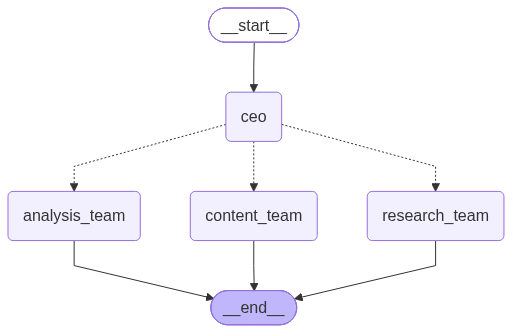

In [21]:
system = create_hierarchical_system()
system

---
## 🚀 Part 4: Running the Hierarchical System

These demos exercise the fully assembled hierarchy: a request comes in, the CEO routes it to the appropriate department, and that department's internal specialists produce the final answer - all in one `.invoke()` call on the parent graph.

### 4.1 📋 Routing Across Multiple Queries

Three different queries, each aimed at a different department, show the CEO's routing decision in action.

In [18]:
# ============================================================================
# DEMO_HIERARCHICAL_ROUTING: Run several queries through the full hierarchy
# ============================================================================
def demo_hierarchical_routing():
    """Demo the full hierarchical system with routing."""
    system = create_hierarchical_system()

    print("Hierarchical Routing Demo:\n")

    queries = [
        "What are the latest trends in large language models?",
        "Write a short blog introduction about AI agents",
        "Should my startup invest in building AI features this year?",
    ]

    for query in queries:
        print(f"Query: {query}")
        print("-" * 40)
        result = system.invoke(
            {"messages": [HumanMessage(content=query)], "final_answer": ""}
        )

        # Show the CEO routing decision
        for msg in result["messages"]:
            if isinstance(msg, AIMessage) and msg.name == "ceo":
                print(f"  {msg.content}")

        # Show the final answer
        print(f"  Final: {result['final_answer'][:200]}...")
        print("=" * 50 + "\n")

### 4.2 🔍 Full Message Trace

To understand exactly how state flows through the hierarchy, this demo prints every message produced at every level - CEO, department lead, and individual specialists - in order.

In [19]:
# ============================================================================
# DEMO_HIERARCHICAL_TRACE: Print the full step-by-step trace through the hierarchy
# ============================================================================
def demo_hierarchical_trace():
    """Show full trace through the hierarchy."""
    system = create_hierarchical_system()

    print("Full Hierarchical Trace:\n")

    result = system.invoke(
        {
            "messages": [
                HumanMessage(
                    content="Research the impact of AI agents on software development productivity"
                )
            ],
            "final_answer": "",
        }
    )

    for i, msg in enumerate(result["messages"]):
        if isinstance(msg, AIMessage):
            label = msg.name or "unknown"
            print(f"[Step {i}] {label}:")
            print(f"  {msg.content[:150]}...")
            print()

---
## ▶️ Run

The original `__main__` guard, kept verbatim. Jupyter sets `__name__` to `"__main__"`, so this cell runs as-is. Uncomment a line to run that demo.

In [22]:
# ============================================================================
# RUN: Execute the demos
# ============================================================================
if __name__ == "__main__":
    # demo_single_department()
    # demo_hierarchical_routing()
    demo_hierarchical_trace()

Full Hierarchical Trace:

[Step 1] ceo:
  [CEO]: Routing to research — This request involves fact-finding and investigation into how AI agents influence software development productivity, whic...

[Step 2] paper_reviewer:
  [PAPER REVIEWER]: - **Automation of Repetitive Tasks**: AI agents can significantly enhance software development productivity by automating repetitive...

[Step 3] web_researcher:
  [WEB RESEARCHER]: Here are some key findings regarding the impact of AI agents on software development productivity:

- **Increased Efficiency**: AI a...

[Step 4] research_lead:
  [RESEARCH LEAD]: The research on the impact of AI agents on software development productivity reveals several key benefits. AI tools significantly enh...



---
## 📝 Summary

### 1. Subgraphs as the unit of composition
- A department (`build_research_team`, `build_content_team`, `build_analysis_team`) is a normal `StateGraph`, compiled independently, and reused as a single node in the parent graph.
- This keeps each department testable in isolation (`demo_single_department`) before it is wired into anything larger.

### 2. One shared state contract
- `TeamState` (`messages` + `final_answer`) is used by the parent graph and every department subgraph, which is what lets a compiled subgraph be dropped in as a node without any adapter code.

### 3. LLM-based routing with structured output
- The CEO supervisor uses `llm.with_structured_output(DepartmentRoute)` to get a typed routing decision (`department` + `reasoning`) instead of parsing free text.
- `route_to_department` reads that decision back out of the last CEO message to pick a conditional edge.

### 4. Fan-out / fan-in inside a department
- The research team demonstrates parallel specialists (`web_researcher`, `paper_reviewer`) feeding into a synthesizing `research_lead` node - the same pattern used at any level of a hierarchy.

### Next Steps
- Compare this to the flatter, single-level supervisor pattern in the earlier notebooks of `04_Multi_Agent_Systems/` to see when a hierarchy is worth the extra structure.
- Try adding a fourth department and confirm the CEO's routing prompt and `route_to_department` logic scale cleanly.
- Explore `07_Advanced_Agentic_Systems/Multi_Agent_Orchestration/` for supervisor and swarm patterns that build on these same ideas.